In [1]:
import scanpy as sc

In [2]:

adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad')
# l_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad')

/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

Cycling TA
Absorptive TA
Colonocytes Early
Secretory Goblet Cells
Colonocytes Laminin
lowQ
Colonocytes
Secretory TA
Colonocytes Late
Follicle associated enterocyte (FAE)
Enterocytes Early
Secretory Tuft Cells
Microfold Cells (M Cells)
Transiently Amplifying Cells (TA)
Epithelial Stem Cells (LGR5+)
Enterocytes
Colonocytes BEST4
EEC L Cells (PYY+)
EEC Enterochromaffin Cells
Enteroendocrine Cells (EEC)
EEC Progenitor
Enterocytes Late
EEC N Cells
Enterocytes BEST4
Secretory Paneth Cells
Plasma Cells
doublet
EEC S Cells (SCT+)
Monocytes


## Searching for rare cell types yet undescribed in scRNA data

### Subset to relevant parent celltype

In [28]:
adata_sub = adata[adata.obs['cell_type_atlas'].isin(['Enteroendocrine Cells (EEC)', 'EEC Progenitor', 'EEC L Cells (PYY+)', 'EEC Enterochromaffin Cells', 'EEC N Cells', 'EEC S Cells (SCT+)'])].copy()
adata_sub

AnnData object with n_obs × n_vars = 2845 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'cont

### recalculate UMAP within parent celltype

In [29]:
sc.pp.pca(adata_sub)
sc.pp.neighbors(adata_sub)
sc.tl.umap(adata_sub)


### show putative marker genes on resulting subset UMAP

In [10]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,130826,195140,0.094287,0.090103,94.224985,318599,12.671692,False,0.076050,1.038674,-1.111607,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,3135,4878,0.001594,0.001593,99.855639,5387,8.591930,False,0.001454,0.667250,-0.527142,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,254820,329289,0.129758,0.122003,90.254951,438457,12.991019,False,0.150211,1.092318,inf,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,136455,175516,0.060628,0.058861,94.805742,204864,12.230107,False,0.063990,1.189661,0.017007,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,57454,70285,0.024555,0.024258,97.919971,82971,11.326258,False,0.025647,1.210943,-0.018293,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,16897,20886,0.006547,0.006525,99.381895,22122,10.004373,False,0.008141,0.529624,-0.047372,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,2644,3151,0.000945,0.000944,99.906749,3193,8.069029,False,0.001483,0.521270,0.030542,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,1438,1631,0.000532,0.000532,99.951732,1799,7.495542,False,0.001226,0.269041,-0.007030,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,2888,3349,0.001025,0.001024,99.900889,3462,8.149891,False,0.001375,0.174228,0.044378,False


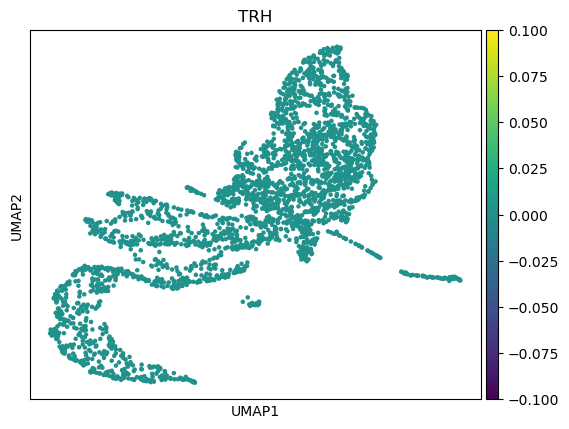

In [11]:
sc.pl.umap(adata_sub, color=['TRH'], gene_symbols='gene_symbol')


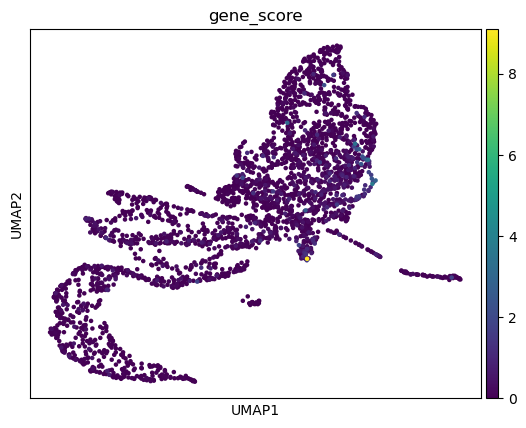

In [12]:
genes = ['SYT10','KLHL4','DGKI','CDH10','NCAM2','IL1RAP','GHR','CDH4','SRRM4','CNTN4']
adata_sub.obs['gene_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1)
sc.pl.umap(adata_sub, color='gene_score')


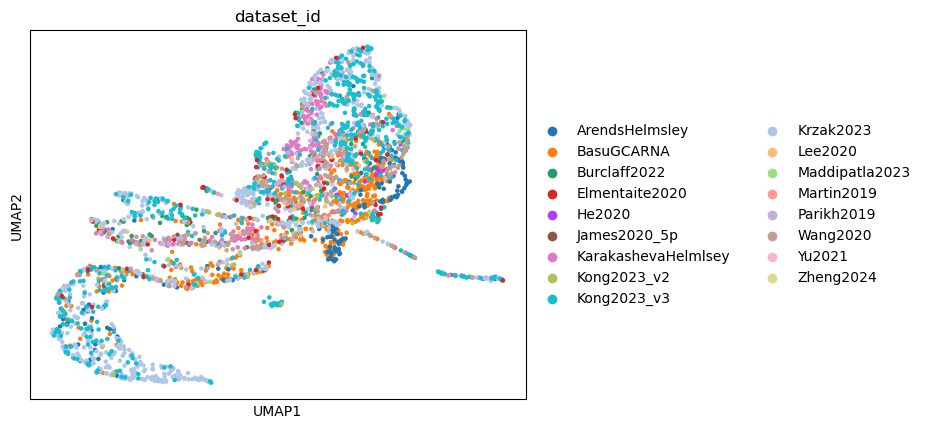

In [13]:
sc.pl.umap(adata_sub, color=['dataset_id'])


In [14]:
adata_sub.obs['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum               2088
ascending colon      460
rectum                78
transverse colon      42
duodenum              40
jejunum               38
colon                 32
descending colon      21
small intestine       20
sigmoid colon         19
caecum                 7
Name: count, dtype: int64

### EEC subtypes per dataset recovery

In [5]:
import numpy as np
import matplotlib.pyplot as plt


X = adata.X

mu = np.array(X.mean(axis=0)).ravel()

# compute std for sparse: sqrt(E[x^2] - (E[x])^2)
mean_sq = np.array(X.power(2).mean(axis=0)).ravel()
var = mean_sq - mu**2
var[var < 0] = 0
sd = np.sqrt(var)
sd[sd == 0] = 1

adata.layers["zscore"] = X.multiply(1 / sd) - mu / sd

/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'zscore' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


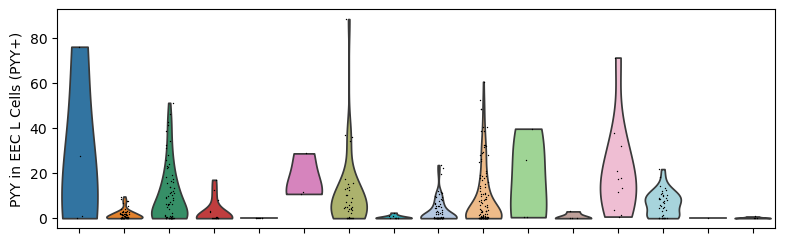

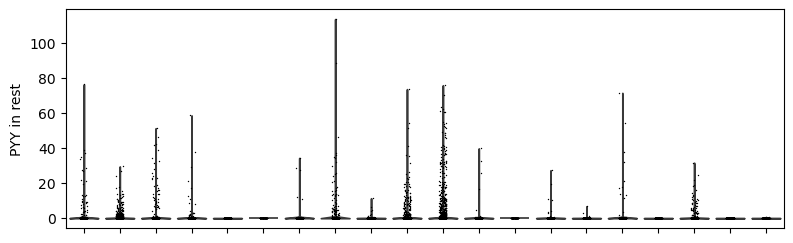

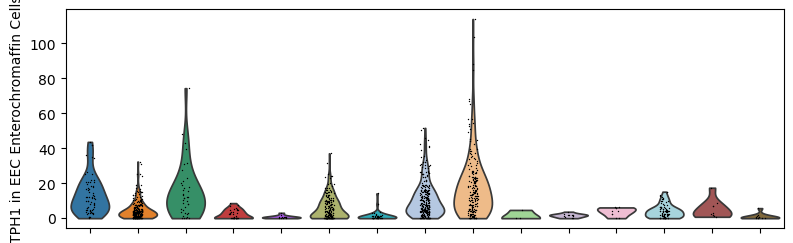

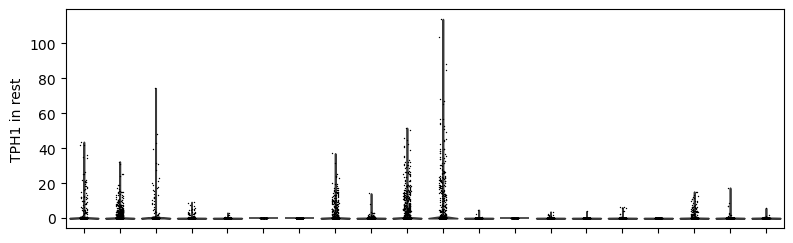

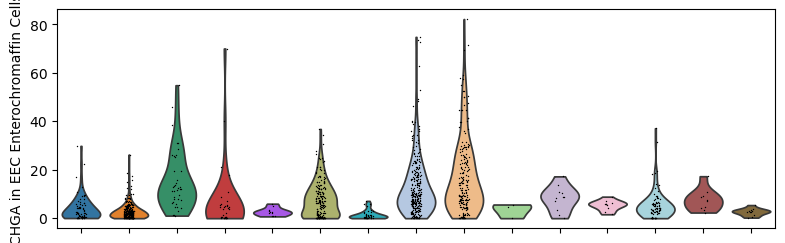

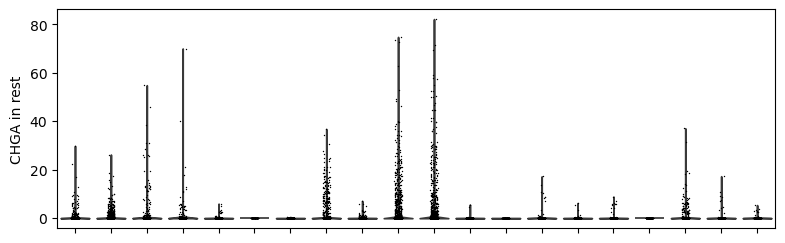

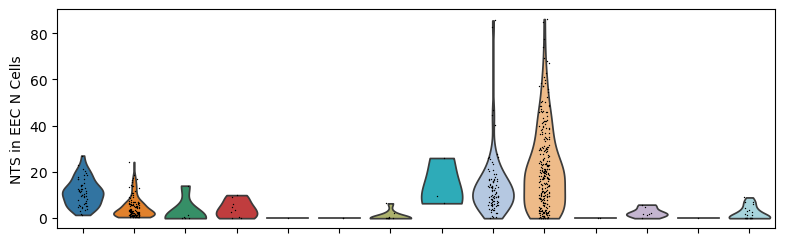

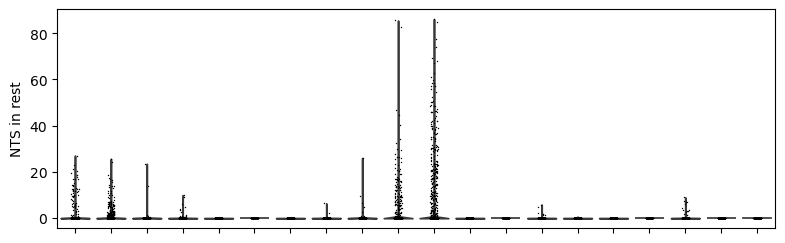

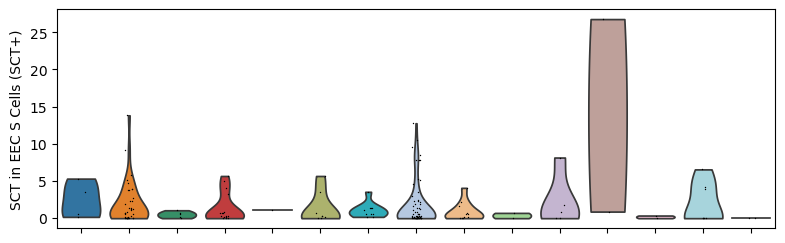

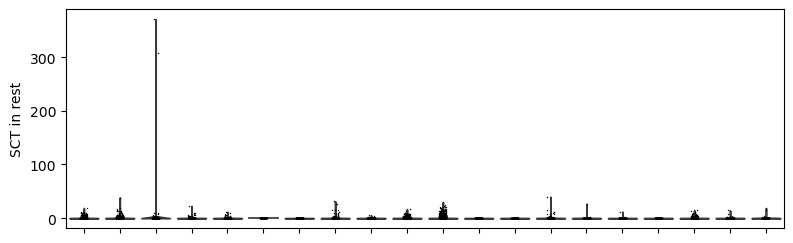

In [17]:
from matplotlib import rcParams

rcParams["figure.figsize"] = (8,3)

# inputs
celltypes = [
    "EEC L Cells (PYY+)",
    "EEC Enterochromaffin Cells",
    "EEC N Cells",
    "EEC S Cells (SCT+)",
]
markers = {
    "EEC L Cells (PYY+)": ["PYY"],
    "EEC Enterochromaffin Cells": ["TPH1", "CHGA"],
    "EEC N Cells": ["NTS"],
    "EEC S Cells (SCT+)": ["SCT"],
}

if "gene_symbol" in adata.var.columns:
    symbol_to_var = dict(zip(adata.var["gene_symbol"], adata.var_names))
else:
    symbol_to_var = {g: g for g in adata.var_names}

def get_var(sym):
    return symbol_to_var.get(sym, None)

import matplotlib.pyplot as plt  # needed for tick edits

def hide_ticks_current_fig():
    fig = plt.gcf()
    for ax in fig.axes:
        ax.set_xticklabels([])
        ax.set_xlabel("")

for ct in celltypes:
    ad_ct = adata[adata.obs["Prelim annotation"] == ct].copy()
    # ad_rest = adata[adata.obs["Prelim annotation"] != ct].copy()

    for sym in markers[ct]:
        var = get_var(sym)
        if var is None:
            print("missing", sym)
            continue

        axs = sc.pl.violin(
            ad_ct,
            keys=[var],
            groupby="dataset_id",
            use_raw=False,
            layer="zscore",
            rotation=None,
            # figsize=(8,3),
            show=False,
            ylabel=f"{sym} in {ct}",
        )
        hide_ticks_current_fig()
        # sc.pl.show()

        axs = sc.pl.violin(
            adata,
            keys=[var],
            groupby="dataset_id",
            use_raw=False,
            layer="zscore",
            rotation=None,
            # figsize=(8,3),
            show=False,
            ylabel=f"{sym} in rest",
        )
        hide_ticks_current_fig()
        # sc.pl.show()


### Secretory - bicarbonate producers

In [16]:
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

Cycling TA
Absorptive TA
Colonocytes Early
Secretory Goblet Cells
Colonocytes Laminin
lowQ
Colonocytes
Secretory TA
Colonocytes Late
Follicle associated enterocyte (FAE)
Enterocytes Early
Secretory Tuft Cells
Microfold Cells (M Cells)
Transiently Amplifying Cells (TA)
Epithelial Stem Cells (LGR5+)
Enterocytes
Colonocytes BEST4
EEC L Cells (PYY+)
EEC Enterochromaffin Cells
Enteroendocrine Cells (EEC)
EEC Progenitor
Enterocytes Late
EEC N Cells
Enterocytes BEST4
Secretory Paneth Cells
Plasma Cells
doublet
EEC S Cells (SCT+)
Monocytes


In [17]:
adata_sub = adata[adata.obs['cell_type_atlas'].isin(['Secretory Goblet Cells', 'Secretory TA', 'Enterocytes', 
                                                     'Enterocytes Early', 'Enterocytes Late', 
                                                     'Colonocytes', 'Colonocytes Early', 'Colonocytes Late', 
                                                     'Colonocytes BEST4', 'Colonocytes Laminin', 'Secretory Tuft Cells',
                                                     'Secretory Paneth Cells'])].copy()

sc.pp.pca(adata_sub); sc.pp.neighbors(adata_sub); sc.tl.umap(adata_sub)

In [18]:
adata_sub.obs['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum                 96502
ascending colon       29115
transverse colon       3762
sigmoid colon          3733
colon                  3663
duodenum               3475
rectum                 2935
jejunum                2593
small intestine        1735
descending colon       1115
caecum                  532
vermiform appendix       18
Name: count, dtype: int64

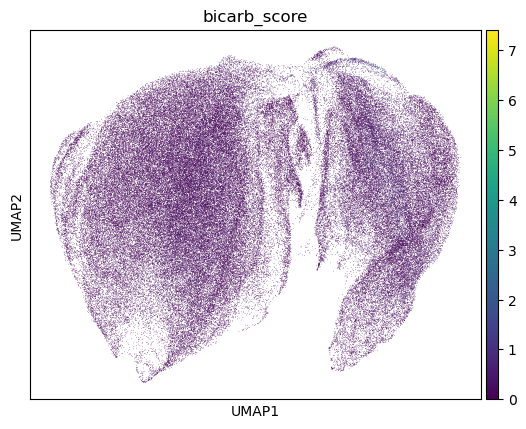

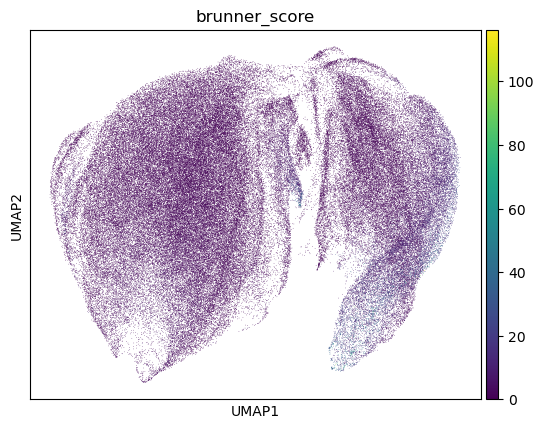

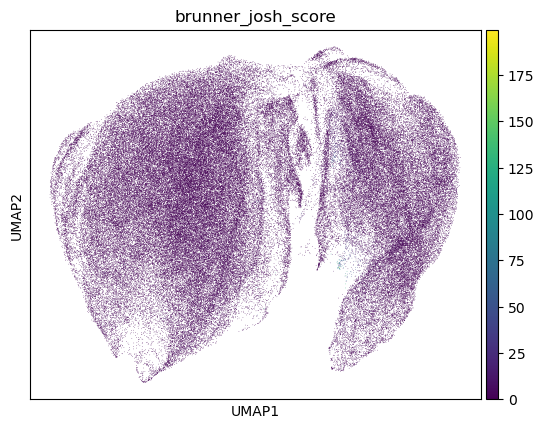

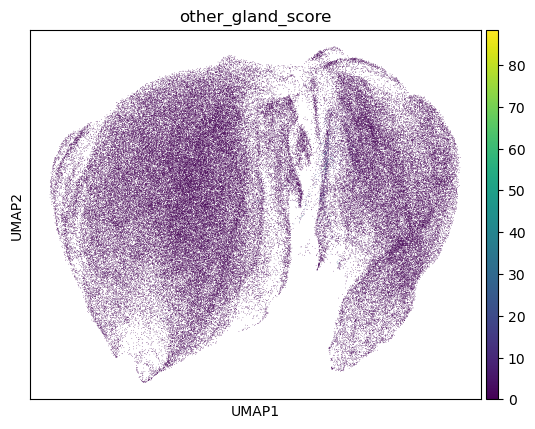

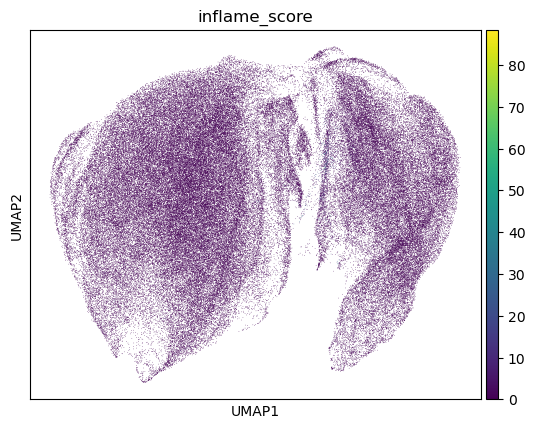

In [19]:
bicarb_score = ['SLC26A3', 'SLC4A4', 'SLC4A10', 'CFTR', 'CA2', 'CA4', 'CA12', 'GUCA2A', 'GUCA2B', 'BEST4', 'OTOP2', 'PIGR', 'MUC6']
brunner_genes = ['MUC6', 'TFF2', 'SLC26A3', 'CA12', 'AQP5']
brunner_genes_josh = ['MUC6','PGC','TFF2','HDAC9','TFF3','AQP5']
other_gland_genes = ['MUC5AC','ANXA10','LYZ','REG4','CAPN8']
inflame_score = [
    "MUC6",    # pyloric‑gland mucin marker
    "PGC",     # pepsinogen C
    "AQP5",    # aquaporin 5
    "BPIFB1",  # bactericidal permeability increasing fold–containing B1
    # stem‑cell/inflammatory program genes enriched in INFLAREs
    "SLC12A2",
    "RGMB",
    "LGR5",
    "LEFTY1",
    "REG1A",
    "OLFM4"
]

adata_sub.obs['bicarb_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_josh_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes_josh)].X.mean(axis=1).A1
adata_sub.obs['other_gland_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(other_gland_genes)].X.mean(axis=1).A1

adata_sub.obs['inflame_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(other_gland_genes)].X.mean(axis=1).A1


sc.pl.umap(adata_sub, color='bicarb_score')

sc.pl.umap(adata_sub, color='brunner_score')

sc.pl.umap(adata_sub, color='brunner_josh_score')

sc.pl.umap(adata_sub, color='other_gland_score')

sc.pl.umap(adata_sub, color='inflame_score')

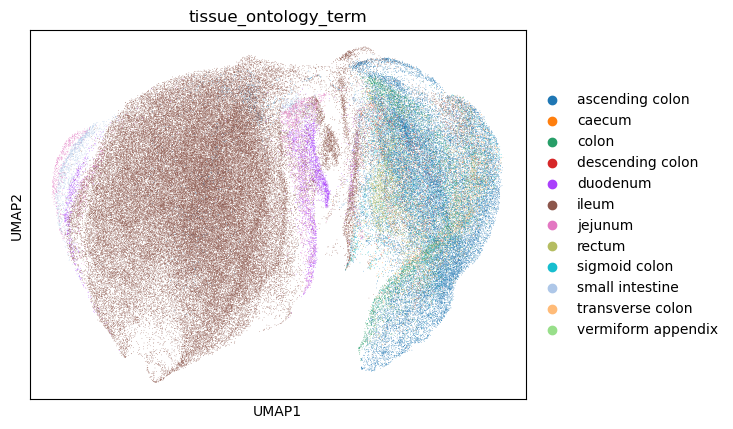

In [20]:
sc.pl.umap(adata_sub, color='tissue_ontology_term')

In [21]:
adata_sub.obs['tissue_free_text'].unique()

['ascending_colon', 'terminal ileum', NaN, 'middle_ileum', 'middle_descending_colon', ..., 'middle_duodenum', 'middle_jejunum', 'middle_ascending_colon', 'ascending colon ', 'Intestine mucosa were freshly sampled at leas...]
Length: 11
Categories (10, object): ['Intestine mucosa were freshly sampled at leas..., 'ascending colon ', 'ascending_colon', 'middle_ascending_colon', ..., 'middle_ileum', 'middle_jejunum', 'middle_transverse_colon', 'terminal ileum']

In [22]:
# sc.pl.umap(adata_sub, color='tissue_ontology_term')

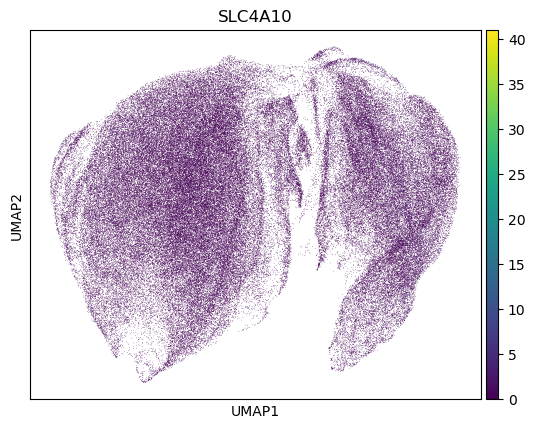

In [23]:
sc.pl.umap(adata_sub, color=['SLC4A10'], gene_symbols='gene_symbol')



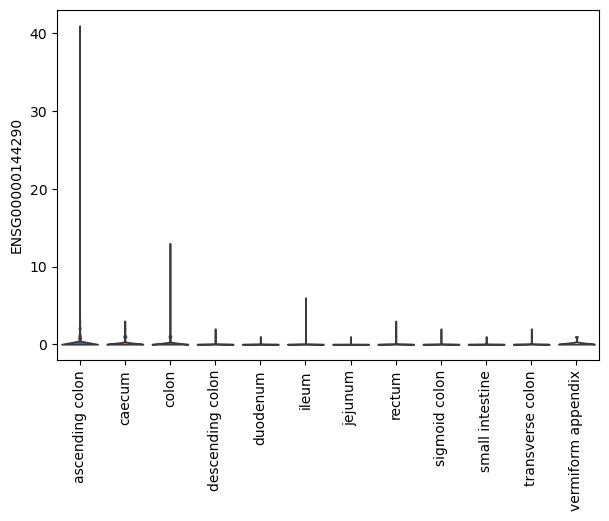

In [24]:
gene = adata_sub.var_names[adata_sub.var['gene_symbol'] == 'SLC4A10'][0]
sc.pl.violin(adata_sub, keys=[gene], groupby='tissue_ontology_term', stripplot=False, rotation=90)

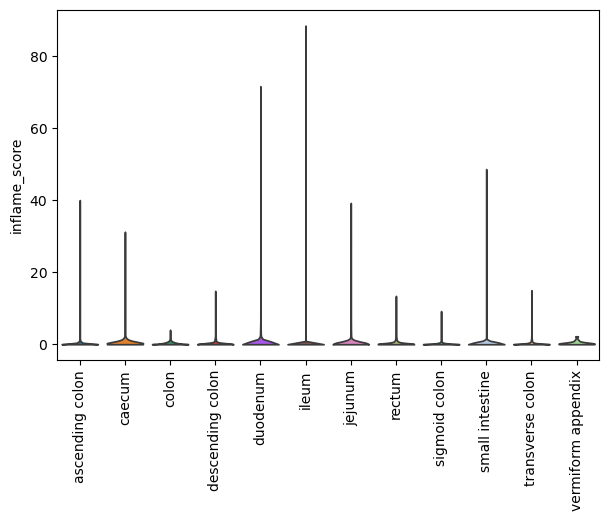

In [25]:
sc.pl.violin(adata_sub, keys=['inflame_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

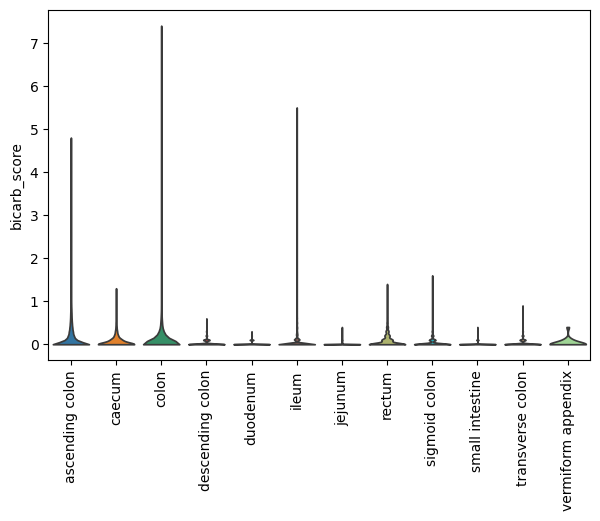

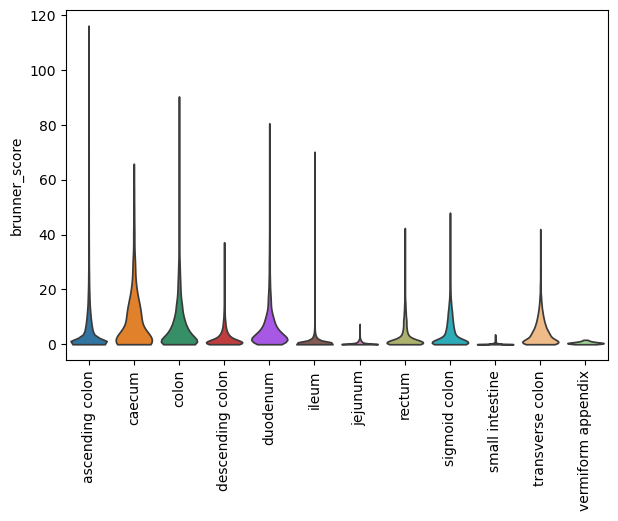

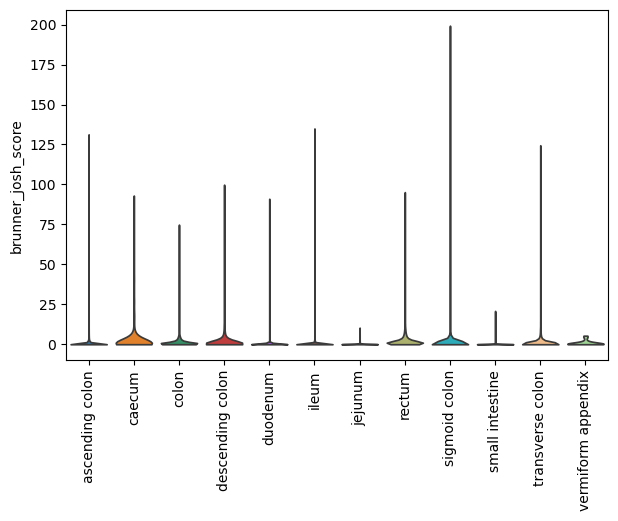

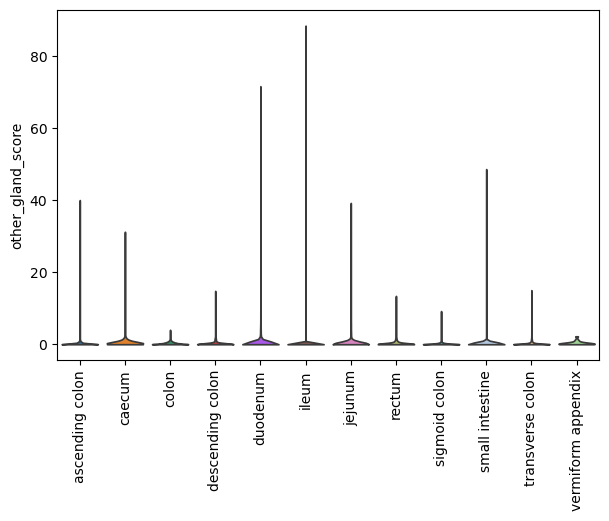

In [26]:
sc.pl.violin(adata_sub, keys=['bicarb_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_josh_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['other_gland_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

In [27]:
adata.obs[['tissue_ontology_term','radial_tissue_term']].drop_duplicates()

,tissue_ontology_term,radial_tissue_term
0,ascending colon,WM
2121,ileum,WM
69754,ileum,LP
70396,rectum,EPI_LP_MUSC
70900,small intestine,EPI_LP_MUSC
72810,colon,EPI_LP
72952,caecum,EPI_LP_MUSC
73035,transverse colon,EPI_LP_MUSC
73773,sigmoid colon,EPI_LP_MUSC
74169,duodenum,EPI_LP
